---------------------- **Creazione del dataset** ----------------------


In [ ]:
# Installing GeoCLIP
!pip install geoclip pandas torch torchvision tqdm

In [ ]:
!pip install geoclip pandas

In [ ]:
# DATASET CREATION V.4 (using visheratin/google_landmarks_places and Bing search)
try:
    import icrawler
except ImportError:
    !pip install -q icrawler pandas datasets tqdm

import os
import csv
import pandas as pd
from datasets import load_dataset
from icrawler.builtin import BingImageCrawler
from tqdm.auto import tqdm
import shutil
import logging
from google.colab import drive
import shutil
import os
import datetime

# 1. Monta Drive
print("🔗 Connessione a Google Drive...")
drive.mount('/content/drive')

# --- CONFIGURAZIONE ---
OUTPUT_DIR = "dataset_italia_city_enhanced_v2"
CSV_FILE = "dataset_train_italia_enhanced_v2.csv"
FAIL_CSV_FILE = "failed_downloads.csv"

# Obiettivo: Scaricare 200 monumenti diversi
TARGET_LANDMARKS_COUNT = 3606
IMAGES_PER_LANDMARK = 20
failed_landmarks = []

def run_italy_hunter_v2():
    print("🌍 FASE 1: Caricamento Dataset Visheratin...")
    try:
        ds_meta = load_dataset("visheratin/google_landmarks_places", split="train")
        df = ds_meta.to_pandas()
    except Exception as e:
        print(f"❌ Errore dataset: {e}")
        return


    REQUIRED_COLS = {'name', 'lat', 'lon'}
    found_cols = {c.lower() for c in df.columns}

    if not REQUIRED_COLS.issubset(found_cols):
        missing = REQUIRED_COLS - found_cols
        raise ValueError(f"❌ Colonne mancanti: {missing}")
    # Auto-detect delle colonne
    cols = list(df.columns)
    # Cerchiamo le colonne chiave in modo flessibile
    c_name = next((c for c in cols if 'name' in c.lower()), 'name')
    c_lat = next((c for c in cols if 'lat' in c.lower()), 'latitude')
    c_lon = next((c for c in cols if 'lon' in c.lower()), 'longitude')
    c_city = next((c for c in cols if 'city' in c.lower()), None) # <--- ECCOLA

    print(f"   ✅ Colonne rilevate: Name='{c_name}', City='{c_city}'")

    # --- FASE 2: FILTRO ITALIA (Geografico) ---
    print("\n🔍 FASE 2: Filtraggio Area Italia...")

    # Usiamo il rettangolo geografico per sicurezza
    geo_mask = (
        (df[c_lat] >= 36.6) & (df[c_lat] <= 47.1) &
        (df[c_lon] >= 6.6) & (df[c_lon] <= 18.5)
    )
    df_italy = df[geo_mask].copy()

    print(f"   🇮🇹 Monumenti in area italiana: {len(df_italy)}")

    # Campionamento Casuale
    if len(df_italy) > TARGET_LANDMARKS_COUNT:
        print(f"   🎲 Seleziono {TARGET_LANDMARKS_COUNT} monumenti casuali...")
        df_target = df_italy.sample(n=TARGET_LANDMARKS_COUNT, random_state=42)
    else:
        df_target = df_italy

    # --- FASE 3: DOWNLOAD CON PARAMETRO CITTÀ ---
    print(f"\n🚀 FASE 3: Avvio Download (Query = Nome + Città + Italy)...")

    if os.path.exists(OUTPUT_DIR): shutil.rmtree(OUTPUT_DIR)
    os.makedirs(OUTPUT_DIR)

    # Inizializza CSV
    with open(CSV_FILE, 'w', newline='') as f:
        # Aggiungo anche la colonna 'city' nel CSV finale per tua comodità
        csv.writer(f).writerow(['image_path', 'latitude', 'longitude', 'landmark_name', 'city'])

    count = 0
    success_landmarks = 0

    # Disattiva log rumorosi di icrawler
    logging.getLogger("icrawler").setLevel(logging.ERROR)

    pbar = tqdm(df_target.iterrows(), total=len(df_target), desc="Crawling")

    for _, row in pbar:
        name = str(row[c_name]).strip()
        lat = row[c_lat]
        lon = row[c_lon]

        # Gestione della Città
        city_val = ""
        if c_city and pd.notna(row[c_city]):
            city_val = str(row[c_city]).strip()

        # --- LA NUOVA QUERY POTENZIATA ---
        # Se la città c'è, la usiamo. Altrimenti usiamo solo il nome.
        if city_val:
            query = f"{name} {city_val} Italy landmark"
        else:
            query = f"{name} Italy landmark"

        # Prepariamo la cartella
        # Nome cartella pulito: "Roma_Colosseo" oppure solo "Colosseo"
        folder_prefix = city_val.replace(" ", "") + "_" if city_val else ""
        clean_name = "".join([c if c.isalnum() else "_" for c in name])[:20]
        folder_name = f"{folder_prefix}{clean_name}"

        save_dir = os.path.join(OUTPUT_DIR, folder_name)
        os.makedirs(save_dir, exist_ok=True)

        try:
            crawler = BingImageCrawler(storage={'root_dir': save_dir}, downloader_threads=4)
            crawler.crawl(keyword=query, max_num=IMAGES_PER_LANDMARK, file_idx_offset='auto')

            # Post-Processing
            files = [f for f in os.listdir(save_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]

            if not files:
                os.rmdir(save_dir)
                continue

            for fname in files:
                full_path = os.path.join(save_dir, fname)
                with open(CSV_FILE, 'a', newline='') as f:
                    # Salviamo anche la città nel CSV
                    csv.writer(f).writerow([full_path, lat, lon, name, city_val])
                count += 1

            success_landmarks += 1
            # Aggiorna la barra mostrando la query attuale
            pbar.set_description(f"📸 {success_landmarks} ok | Q: {query[:30]}...")

        except Exception as e:
          failed_landmarks.append({'name': name, 'error': str(e)})
          continue

    print(f"\n🏆 FINE! Dataset creato.")
    print(f"   Immagini totali: {count}")
    print(f"   CSV salvato: {CSV_FILE}")

if __name__ == "__main__":
    run_italy_hunter_v2()
    if failed_landmarks:
      pd.DataFrame(failed_landmarks).to_csv('failed_downloads.csv')
    # SAVING RAW DATASET INTO DRIVE

    # --- CONFIGURAZIONE ---
    # Nomi delle cartelle create dallo script "Italy Hunter v2"
    LOCAL_IMAGE_DIR = "dataset_italia_city_enhanced_v2"
    LOCAL_CSV_FILE = "dataset_train_italia_enhanced_v2.csv"

    # Destinazione su Drive
    # Aggiungo una sottocartella specifica per separare il grezzo dal pulito
    DRIVE_BASE_PATH = "/content/drive/MyDrive/Unipd/Computer Vision Project/Dataset_GeoClip"
    BACKUP_DIR = os.path.join(DRIVE_BASE_PATH, "Backup_Raw_PreClean_V2")

    # --- ESECUZIONE ---
    if not os.path.exists(LOCAL_IMAGE_DIR):
        print(f"❌ ERRORE: Non trovo la cartella immagini '{LOCAL_IMAGE_DIR}'.")
        print("   Hai eseguito lo script di download prima?")
    else:
        # Crea cartella su Drive se non esiste
        os.makedirs(BACKUP_DIR, exist_ok=True)

        # 1. Zippiamo le immagini
        print(f"📦 Compressione cartella '{LOCAL_IMAGE_DIR}'...")
        # Aggiungiamo un timestamp per sicurezza
        timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M")
        zip_filename = f"dataset_raw_images_{timestamp}"

        shutil.make_archive(zip_filename, 'zip', LOCAL_IMAGE_DIR)

        # 2. Copia su Drive
        print(f"🚀 Caricamento su Drive in: {BACKUP_DIR}")

        # Copia ZIP
        shutil.copy(f"{zip_filename}.zip", os.path.join(BACKUP_DIR, "images_raw.zip"))
        print("   ✅ ZIP Immagini copiato.")

        # Copia CSV
        if os.path.exists(LOCAL_CSV_FILE):
            shutil.copy(LOCAL_CSV_FILE, os.path.join(BACKUP_DIR, "metadata_raw.csv"))
            print("   ✅ CSV Metadata copiato.")
        else:
            print("   ⚠️ CSV non trovato!")

        # Copia CSV
        if os.path.exists(FAIL_CSV_FILE):
            shutil.copy(FAIL_CSV_FILE, os.path.join(BACKUP_DIR, "failed_downloads.csv"))
            print("   ✅ CSV Fail copiato.")
        else:
            print("   ⚠️ CSV non trovato!")

        print("\n🏆 BACKUP COMPLETATO!")
        print("   Ora puoi procedere con la pulizia (CLIP) senza paura.")

🔗 Connessione a Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🌍 FASE 1: Caricamento Dataset Visheratin...
   ✅ Colonne rilevate: Name='category_name', City='city'

🔍 FASE 2: Filtraggio Area Italia...
   🇮🇹 Monumenti in area italiana: 3606

🚀 FASE 3: Avvio Download (Query = Nome + Città + Italy)...


Crawling:   0%|          | 0/3606 [00:00<?, ?it/s]

Output streaming troncato alle ultime 5000 righe.
ERROR:downloader:Response status code 404, file https://upload.wikimedia.org/wikipedia/commons/thumb/4/40/Lac_de_Bret_-_panoramio_(108).jpg
ERROR:downloader:Response status code 429, file https://upload.wikimedia.org/wikipedia/commons/thumb/9/9c/San_Biagio_degli_Armeni.jpg
ERROR:downloader:Response status code 429, file https://upload.wikimedia.org/wikipedia/commons/thumb/e/eb/2016_San_Biagio_degli_Armeni.jpg
ERROR:downloader:Response status code 429, file https://upload.wikimedia.org/wikipedia/commons/thumb/0/0d/Palazzo_Sacchetti_sulla_Strada_Giulia_-_Plate_71_-_Giuseppe_Vasi.jpg
ERROR:downloader:Response status code 429, file https://upload.wikimedia.org/wikipedia/commons/thumb/2/24/RomaSanBiagioDeMercato.jpg
ERROR:downloader:Response status code 429, file https://upload.wikimedia.org/wikipedia/commons/thumb/d/df/San_Biagio_de_Mercato_3.jpg
ERROR:downloader:Response status code 429, file https://upload.wikimedia.org/wikipedia/commons/


🏆 FINE! Dataset creato.
   Immagini totali: 103090
   CSV salvato: dataset_train_italia_enhanced_v2.csv
📦 Compressione cartella 'dataset_italia_city_enhanced_v2'...
🚀 Caricamento su Drive in: /content/drive/MyDrive/Unipd/Computer Vision Project/Dataset_GeoClip/Backup_Raw_PreClean_V2
   ✅ ZIP Immagini copiato.
   ✅ CSV Metadata copiato.

🏆 BACKUP COMPLETATO!
   Ora puoi procedere con la pulizia (CLIP) senza paura.


In [ ]:
# SAVING RAW DATASET INTO DRIVE
from google.colab import drive
import shutil
import os
import datetime

# 1. Monta Drive
print("🔗 Connessione a Google Drive...")
drive.mount('/content/drive')

# --- CONFIGURAZIONE ---
# Nomi delle cartelle create dallo script "Italy Hunter v2"
LOCAL_IMAGE_DIR = "dataset_italia_city_enhanced_v2"
LOCAL_CSV_FILE = "dataset_train_italia_enhanced_v2.csv"

# Destinazione su Drive
# Aggiungo una sottocartella specifica per separare il grezzo dal pulito
DRIVE_BASE_PATH = "/content/drive/MyDrive/Unipd/Computer Vision Project/Dataset_GeoClip"
BACKUP_DIR = os.path.join(DRIVE_BASE_PATH, "Backup_Raw_PreClean_V2")

# --- ESECUZIONE ---
if not os.path.exists(LOCAL_IMAGE_DIR):
    print(f"❌ ERRORE: Non trovo la cartella immagini '{LOCAL_IMAGE_DIR}'.")
    print("   Hai eseguito lo script di download prima?")
else:
    # Crea cartella su Drive se non esiste
    os.makedirs(BACKUP_DIR, exist_ok=True)

    # 1. Zippiamo le immagini
    print(f"📦 Compressione cartella '{LOCAL_IMAGE_DIR}'...")
    # Aggiungiamo un timestamp per sicurezza
    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M")
    zip_filename = f"dataset_raw_images_{timestamp}"

    shutil.make_archive(zip_filename, 'zip', LOCAL_IMAGE_DIR)

    # 2. Copia su Drive
    print(f"🚀 Caricamento su Drive in: {BACKUP_DIR}")

    # Copia ZIP
    shutil.copy(f"{zip_filename}.zip", os.path.join(BACKUP_DIR, "images_raw.zip"))
    print("   ✅ ZIP Immagini copiato.")

    # Copia CSV
    if os.path.exists(LOCAL_CSV_FILE):
        shutil.copy(LOCAL_CSV_FILE, os.path.join(BACKUP_DIR, "metadata_raw.csv"))
        print("   ✅ CSV Metadata copiato.")
    else:
        print("   ⚠️ CSV non trovato!")

    print("\n🏆 BACKUP COMPLETATO!")
    print("   Ora puoi procedere con la pulizia (CLIP) senza paura.")

🔗 Connessione a Google Drive...
Mounted at /content/drive
📦 Compressione cartella 'dataset_italia_city_enhanced_v2'...
🚀 Caricamento su Drive in: /content/drive/MyDrive/Unipd/Computer Vision Project/Dataset_GeoClip/Backup_Raw_PreClean_V2
   ✅ ZIP Immagini copiato.
   ✅ CSV Metadata copiato.

🏆 BACKUP COMPLETATO!
   Ora puoi procedere con la pulizia (CLIP) senza paura.


In [ ]:
# LOADING RAW DATASET FROM DRIVE
from google.colab import drive
import shutil
import os

# 1. Monta Drive
print("🔗 Connessione a Google Drive...")
drive.mount('/content/drive')

# --- CONFIGURAZIONE PERCORSI ---
# Il percorso dove hai salvato il backup "Raw"
DRIVE_SOURCE_DIR = "/content/drive/MyDrive/Unipd/Computer Vision Project/Dataset_GeoClip/Backup_Raw_PreClean_V2"

# I nomi dei file su Drive (dallo script di backup precedente)
ZIP_NAME_DRIVE = "images_raw.zip"
CSV_NAME_DRIVE = "metadata_raw.csv"

# Dove li mettiamo in Colab (nomi attesi dallo script di pulizia)
LOCAL_IMAGE_DIR = "dataset_italia_city_enhanced"
LOCAL_CSV_NAME = "dataset_train_italia_enhanced.csv"

# --- ESECUZIONE ---

# 1. PULIZIA AMBIENTE (Per essere sicuri di sovrascrivere tutto)
print("🧹 Pulizia ambiente locale (rimozione vecchi dati)...")
if os.path.exists(LOCAL_IMAGE_DIR):
    shutil.rmtree(LOCAL_IMAGE_DIR) # Cancella cartella immagini
if os.path.exists(LOCAL_CSV_NAME):
    os.remove(LOCAL_CSV_NAME)      # Cancella CSV
if os.path.exists("temp_images.zip"):
    os.remove("temp_images.zip")

# 2. COPIA DA DRIVE
print(f"🚀 Recupero dati da: {DRIVE_SOURCE_DIR}")
src_zip = os.path.join(DRIVE_SOURCE_DIR, ZIP_NAME_DRIVE)
src_csv = os.path.join(DRIVE_SOURCE_DIR, CSV_NAME_DRIVE)

if not os.path.exists(src_zip):
    print(f"❌ ERRORE: Non trovo il file {src_zip}")
    print("   Controlla che il backup esista su Drive.")
else:
    # Copia CSV e lo rinomina come serve a noi
    shutil.copy(src_csv, LOCAL_CSV_NAME)
    print("   ✅ CSV Metadata recuperato.")

    # Copia ZIP
    shutil.copy(src_zip, "temp_images.zip")
    print("   ✅ ZIP Immagini copiato.")

    # 3. ESTRAZIONE
    print(f"📦 Estrazione in corso nella cartella '{LOCAL_IMAGE_DIR}'...")

    # Creiamo la cartella di destinazione
    os.makedirs(LOCAL_IMAGE_DIR, exist_ok=True)

    # Scompattiamo
    # Nota: Usiamo unzip -d per dire "metti i file QUI DENTRO"
    os.system(f'unzip -q temp_images.zip -d "{LOCAL_IMAGE_DIR}"')

    # Rimuoviamo lo zip temporaneo per risparmiare spazio
    os.remove("temp_images.zip")

    print("\n🏆 RIPRISTINO COMPLETATO!")
    print(f"   📂 Cartella pronta: {LOCAL_IMAGE_DIR}")
    print(f"   📄 File CSV pronto: {LOCAL_CSV_NAME}")
    print("   👉 Ora puoi lanciare lo script di pulizia CLIP.")

🔗 Connessione a Google Drive...
Mounted at /content/drive
🧹 Pulizia ambiente locale (rimozione vecchi dati)...
🚀 Recupero dati da: /content/drive/MyDrive/Unipd/Computer Vision Project/Dataset_GeoClip/Backup_Raw_PreClean_V2
   ✅ CSV Metadata recuperato.
   ✅ ZIP Immagini copiato.
📦 Estrazione in corso nella cartella 'dataset_italia_city_enhanced'...

🏆 RIPRISTINO COMPLETATO!
   📂 Cartella pronta: dataset_italia_city_enhanced
   📄 File CSV pronto: dataset_train_italia_enhanced.csv
   👉 Ora puoi lanciare lo script di pulizia CLIP.


---------------------- **Pulizia dataset** ----------------------

In [ ]:
# Libraries for dataset cleaning
# 1. Rimuoviamo la libreria 'clip' sbagliata (se esiste)
!pip uninstall -y clip

# 2. Installiamo la vera libreria CLIP di OpenAI direttamente da GitHub
!pip install -q git+https://github.com/openai/CLIP.git

# 3. Installiamo ftfy e regex (che servono a CLIP)
!pip install -q ftfy regex tqdm

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.3 MB/s eta 0:00:00


In [ ]:
import torch
import clip
from PIL import Image
import os
import pandas as pd
from tqdm.auto import tqdm

# Configurazione
DATASET_DIR = "dataset_italia_city_enhanced"
KEEP_THRESHOLD = 0.60
BATCH_SIZE = 32

# 1. Caricamento CLIP
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"⚙️ Caricamento modello CLIP su {device}...")
model, preprocess = clip.load("ViT-B/32", device=device)

text_inputs = torch.cat([clip.tokenize(c) for c in [
    "a photo of an outdoor historical landmark or building",
    "a selfie or a portrait of a person",
    "a photo of food or drink",
    "an indoor view of a room or hotel",
    "a map or a screenshot"
]]).to(device)

# 2. PREPARAZIONE LISTA FILE
print("📂 Indicizzazione file in corso...")
all_images = []
for root, dirs, files in os.walk(DATASET_DIR):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            all_images.append(os.path.join(root, file))

print(f"🧹 INIZIO PULIZIA SU {len(all_images)} IMMAGINI...")

removed_count = 0
total_count = len(all_images)
failed_clean = []  # ✅ SPOSTATO FUORI dal loop!

# 3. CICLO A BATCH
pbar = tqdm(range(0, len(all_images), BATCH_SIZE), desc="Cleaning")

for i in pbar:
    batch_paths = all_images[i:i+BATCH_SIZE]
    batch_images = []
    valid_paths = []  # ✅ Per tracciare quali immagini sono valide

    # Carica il batch
    for file_path in batch_paths:
        try:
            img = preprocess(Image.open(file_path))
            batch_images.append(img)
            valid_paths.append(file_path)
        except Exception as e:
            tqdm.write(f"⚠️ Errore su {file_path}: {e}")
            failed_clean.append({'file': file_path, 'error': str(e)})

    if not batch_images:
        continue

    # Processa il batch
    batch_tensor = torch.stack(batch_images).to(device)  # ✅ stack invece di cat

    with torch.no_grad():
        image_features = model.encode_image(batch_tensor)
        text_features = model.encode_text(text_inputs)

        image_features /= image_features.norm(dim=-1, keepdim=True)
        text_features /= text_features.norm(dim=-1, keepdim=True)
        similarity = (100.0 * image_features @ text_features.T).softmax(dim=-1)

        is_landmark_scores = similarity[:, 0]  # ✅ Tutti gli score, non solo il primo!

    # Rimuovi le immagini sotto threshold
    for file_path, score in zip(valid_paths, is_landmark_scores):
        if score.item() < KEEP_THRESHOLD:
            os.remove(file_path)
            removed_count += 1

    # Aggiorna progress bar
    pbar.set_postfix({"Rimosse": removed_count})

# Salva errori se ce ne sono
if failed_clean:
    pd.DataFrame(failed_clean).to_csv('failed_clean.csv', index=False)
    print(f"⚠️ {len(failed_clean)} immagini con errori salvate in failed_clean.csv")

print(f"\n✨ PULIZIA COMPLETATA!")
print(f"   Immagini iniziali: {total_count}")
print(f"   Immagini rimosse: {removed_count}")
print(f"   Immagini rimaste: {total_count - removed_count}")

⚙️ Caricamento modello CLIP su cuda...


100%|████████████████████████████████████████| 338M/338M [00:01<00:00, 260MiB/s]


📂 Indicizzazione file in corso...
🧹 INIZIO PULIZIA SU 66887 IMMAGINI...


Cleaning:   0%|          | 0/66887 [00:00<?, ?img/s]

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(



✨ PULIZIA COMPLETATA!
   Immagini iniziali: 66887
   Immagini rimosse: 27782
   Immagini rimaste: 39105


In [ ]:
# UPDATE CSV POST CLEANING
import pandas as pd
import os

# Nomi dei file attuali
OLD_CSV = "dataset_train_italia_enhanced.csv"
CLEAN_CSV = "dataset_italia_CLEANED.csv"
DATASET_DIR = "dataset_italia_city_enhanced" # La cartella delle immagini

print("🔄 Aggiornamento del CSV post-pulizia...")

if os.path.exists(OLD_CSV):
    # Leggi il CSV vecchio
    df = pd.read_csv(OLD_CSV)
    original_len = len(df)

    # FILTRO MAGICO: Tieni la riga SOLO se il file esiste ancora sul disco
    # (os.path.exists controlla se il file c'è davvero)
    df_clean = df[df['image_path'].apply(os.path.exists)]

    # Salviamo il nuovo CSV
    df_clean.to_csv(CLEAN_CSV, index=False)

    print(f"✅ CSV Aggiornato!")
    print(f"   Righe originali: {original_len}")
    print(f"   Righe valide rimaste: {len(df_clean)}")
    print(f"   File salvato come: {CLEAN_CSV}")
else:
    print("❌ Attenzione: Non trovo il file CSV originale.")

🔄 Aggiornamento del CSV post-pulizia...
✅ CSV Aggiornato!
   Righe originali: 103090
   Righe valide rimaste: 0
   File salvato come: dataset_italia_CLEANED.csv


In [ ]:
# SAVING DATASET INTO GOOGLE DRIVE
from google.colab import drive
import shutil
import os

# 1. Monta Google Drive
print("🔗 Connessione a Google Drive...")
drive.mount('/content/drive')

# --- CONFIGURAZIONE ---
# Il percorso con gli spazi va benissimo, basta che sia tra virgolette
DRIVE_DESTINATION_FOLDER = "/content/drive/MyDrive/Unipd/Computer Vision Project/Dataset_GeoClip_CLEANED"

# Crea la cartella se non esiste (os.makedirs gestisce gli spazi da solo)
if not os.path.exists(DRIVE_DESTINATION_FOLDER):
    print(f"📂 Creo la cartella: {DRIVE_DESTINATION_FOLDER}")
    os.makedirs(DRIVE_DESTINATION_FOLDER)
else:
    print(f"📂 Cartella trovata: {DRIVE_DESTINATION_FOLDER}")

# 2. Creazione dello ZIP (della cartella locale delle immagini)
# Assicurati che "dataset_italia_mixed_auto" sia il nome della cartella che hai creato con lo script precedente
LOCAL_DATASET_FOLDER = "dataset_italia_city_enhanced"

print("📦 Compressione del dataset in corso...")
# Crea un file temporaneo 'dataset_backup.zip' nell'ambiente Colab
shutil.make_archive("dataset_backup", 'zip', LOCAL_DATASET_FOLDER)

# 3. Copia su Drive
print(f"🚀 Caricamento file su Drive...")

# Percorsi di destinazione
zip_dest = os.path.join(DRIVE_DESTINATION_FOLDER, "dataset_images.zip")
csv_dest = os.path.join(DRIVE_DESTINATION_FOLDER, "dataset_metadata.csv")

# Copia lo ZIP
shutil.copy("dataset_backup.zip", zip_dest)
print(f"   ✅ ZIP salvato in: {zip_dest}")

# Copia il CSV Pulito (assumendo tu abbia fatto lo step di pulizia CSV prima)
# Se il file si chiama diversamente, cambia "dataset_italia_CLEANED.csv"
if os.path.exists("dataset_italia_CLEANED.csv"):
    shutil.copy("dataset_italia_CLEANED.csv", csv_dest)
    print(f"   ✅ CSV salvato in: {csv_dest}")
else:
    print("   ⚠️ Attenzione: File CSV pulito non trovato. Hai eseguito lo script di aggiornamento CSV?")

print("\n🏆 SALVATAGGIO COMPLETATO SU DRIVE!")

🔗 Connessione a Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📂 Creo la cartella: /content/drive/MyDrive/Unipd/Computer Vision Project/Dataset_GeoClip_CLEANED
📦 Compressione del dataset in corso...
🚀 Caricamento file su Drive...
   ✅ ZIP salvato in: /content/drive/MyDrive/Unipd/Computer Vision Project/Dataset_GeoClip_CLEANED/dataset_images.zip
   ✅ CSV salvato in: /content/drive/MyDrive/Unipd/Computer Vision Project/Dataset_GeoClip_CLEANED/dataset_metadata.csv

🏆 SALVATAGGIO COMPLETATO SU DRIVE!


In [1]:
# COPY DATASET FROM DRIVE
from google.colab import drive
import shutil
import os

# 1. Monta Google Drive
print("🔗 Connessione a Google Drive...")
drive.mount('/content/drive')

# --- CONFIGURAZIONE PERCORSO DRIVE ---
# Copia ESATTAMENTE il percorso dove hai salvato i file.
DRIVE_SOURCE_FOLDER = "/content/drive/MyDrive/Unipd/Computer Vision Project/Dataset_GeoClip_CLEANED"

# Nomi dei file che ci aspettiamo di trovare
ZIP_NAME = "dataset_images.zip"
CSV_NAME = "dataset_coordinate_FINGERPRINT.csv"

# Cartella locale dove metteremo le immagini scompattate
LOCAL_EXTRACT_DIR = "dataset_reale"

# --- ESECUZIONE ---
print(f"🔄 Cerco i file in: {DRIVE_SOURCE_FOLDER}")

# Costruiamo i percorsi completi (Source = Drive, Dest = Colab locale)
src_zip = os.path.join(DRIVE_SOURCE_FOLDER, ZIP_NAME)
src_csv = os.path.join(DRIVE_SOURCE_FOLDER, CSV_NAME)

# Controllo di sicurezza
if not os.path.exists(src_zip):
    print(f"❌ ERRORE: Non trovo il file {src_zip}")
    print("   Controlla di aver scritto bene il percorso e che il file esista su Drive.")
else:
    # 2. Copia i file da Drive a Colab (nella cartella corrente ".")
    print("🚀 Copia in corso da Drive al Runtime (veloce)...")
    shutil.copy(src_zip, ".")
    shutil.copy(src_csv, ".")
    print("   ✅ File copiati.")

    # 3. Estrazione ZIP
    print(f"📦 Estrazione immagini in '{LOCAL_EXTRACT_DIR}'...")

    # Usiamo un comando di sistema per scompattare (è più veloce di Python per tanti file)
    # Nota le virgolette extra f'"{ZIP_NAME}"' per sicurezza sugli spazi, anche se qui non ce ne sono
    os.system(f'unzip -q "{ZIP_NAME}" -d "{LOCAL_EXTRACT_DIR}"')

    print("\n🏆 TUTTO PRONTO!")
    print(f"   📂 Cartella Immagini: {LOCAL_EXTRACT_DIR}")
    print(f"   📄 File CSV Metadata: {CSV_NAME}")

    # Piccola verifica
    num_files = len(os.listdir(LOCAL_EXTRACT_DIR))
    print(f"   📊 Immagini recuperate: {num_files}")

🔗 Connessione a Google Drive...
Mounted at /content/drive
🔄 Cerco i file in: /content/drive/MyDrive/Unipd/Computer Vision Project/Dataset_GeoClip_CLEANED
🚀 Copia in corso da Drive al Runtime (veloce)...
   ✅ File copiati.
📦 Estrazione immagini in 'dataset_reale'...

🏆 TUTTO PRONTO!
   📂 Cartella Immagini: dataset_reale
   📄 File CSV Metadata: dataset_coordinate_FINGERPRINT.csv
   📊 Immagini recuperate: 3257


---------------------- **Training** ----------------------

In [2]:
!pip install geoclip pandas torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 MB 18.8 MB/s eta 0:00:00


In [3]:
import pandas as pd
# NUOVA CELLA - Inserisci PRIMA della cella 15
def verify_dataset_integrity(csv_path, image_dir):
    """Verifica che tutte le immagini nel CSV esistano"""
    df = pd.read_csv(csv_path)

    print(f"🔍 Verifica integrità dataset...")
    print(f"   Righe nel CSV: {len(df)}")

    missing = []
    for idx, row in df.iterrows():
        img_path = os.path.join(image_dir, row['path'])
        if not os.path.exists(img_path):
            missing.append(idx)

    if missing:
        print(f"❌ {len(missing)} immagini mancanti!")
        print(f"   Prime 5: {missing[:5]}")

        # Crea versione pulita
        df_clean = df.drop(missing)
        clean_csv = csv_path.replace('.csv', '_verified.csv')
        df_clean.to_csv(clean_csv, index=False)
        print(f"   ✅ CSV pulito salvato: {clean_csv}")
        return clean_csv
    else:
        print(f"✅ Tutte le {len(df)} immagini sono presenti!")
        return csv_path

# Usa questa funzione
CSV_FILE = verify_dataset_integrity("dataset_metadata.csv", "dataset_reale")

🔍 Verifica integrità dataset...
   Righe nel CSV: 38972
✅ Tutte le 38972 immagini sono presenti!


In [ ]:
# Nuova cella all'inizio del notebook
!pip uninstall -y torch torchvision torchaudio
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

# Riavvia runtime dopo questo
print("✅ PyTorch reinstallato. RIAVVIA IL RUNTIME (Runtime → Restart runtime)")

Found existing installation: torch 2.9.0+cu126
Uninstalling torch-2.9.0+cu126:
  Successfully uninstalled torch-2.9.0+cu126
Found existing installation: torchvision 0.24.0+cu126
Uninstalling torchvision-0.24.0+cu126:
  Successfully uninstalled torchvision-0.24.0+cu126
Found existing installation: torchaudio 2.9.0+cu126
Uninstalling torchaudio-2.9.0+cu126:
  Successfully uninstalled torchaudio-2.9.0+cu126
Looking in indexes: https://download.pytorch.org/whl/cu118
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 87.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.6/875.6 kB 65.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 118.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 663.9/663.9 MB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.9/417.9 MB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.4/168.4 MB 7.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from geoclip.model import GeoCLIP
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split
from torchvision import transforms
from tqdm import tqdm
from google.colab import drive
import shutil
import os
# --- CONFIGURAZIONE ---
CSV_FILE = "dataset_metadata.csv"
BATCH_SIZE = 8

# --- VINCOLI GEOGRAFICI (IL RETTANGOLO ITALIA) ---
# Latitudine: Da Lampedusa (35) alle Alpi (48)
# Longitudine: Dal Piemonte (6) alla Puglia (19)
MIN_LAT, MAX_LAT = 35.0, 48.0
MIN_LON, MAX_LON = 6.0, 19.0

# 1. Dataset con Normalizzazione (0-1)
class ItalyGeoDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row['path'] # Changed from 'image_path' to 'path'

        # NORMALIZZAZIONE: Trasformiamo le coordinate reali in un numero tra 0 e 1
        # Esempio: Se Lat è 35 (Min) diventa 0. Se è 48 (Max) diventa 1.
        lat, lon = row['lat'], row['lon']

        # Validazione
        if pd.isna(lat) or pd.isna(lon):
            raise ValueError(f"Coordinate invalide in riga {idx}")

        # Clipping per sicurezza
        lat = max(MIN_LAT, min(MAX_LAT, lat))
        lon = max(MIN_LON, min(MAX_LON, lon))

        norm_lat = (lat - MIN_LAT) / (MAX_LAT - MIN_LAT)
        norm_lon = (lon - MIN_LON) / (MAX_LON - MIN_LON)

        target = torch.tensor([norm_lat, norm_lon], dtype=torch.float32)

        try:
            image = Image.open(os.path.join("dataset_reale", img_path)).convert("RGB") # Added os.path.join("dataset_reale", img_path)
        except:
            image = Image.new('RGB', (224, 224), color='black')

        if self.transform:
            image = self.transform(image)

        return image, target

# Trasformazioni (Standard GeoClip)
train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.48145466, 0.4578275, 0.40821073],
                         std=[0.26862954, 0.26130258, 0.27577711]),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),  # No augmentation per validation
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.48145466, 0.4578275, 0.40821073],
                         std=[0.26862954, 0.26130258, 0.27577711]),
])

# 2. Caricamento Dati
full_df = pd.read_csv(CSV_FILE)
# Filtriamo eventuali dati sporchi fuori dall'Italia (sicurezza)
full_df = full_df[
    (full_df['lat'] >= MIN_LAT) & (full_df['lat'] <= MAX_LAT) & # Changed from 'latitude' to 'lat'
    (full_df['lon'] >= MIN_LON) & (full_df['lon'] <= MAX_LON)   # Changed from 'longitude' to 'lon'
]

train_df, val_df = train_test_split(full_df, test_size=0.2, random_state=42)
train_loader = DataLoader(ItalyGeoDataset(train_df, train_transform), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(ItalyGeoDataset(val_df, val_transform), batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
try:
    del model
    print("🗑️ Vecchio modello eliminato dalla memoria.")
except:
    print("Mmm, non c'era nessun modello.")

Mmm, non c'era nessun modello.


In [ ]:
# ===== CELLA DIAGNOSTICA (FIXED) =====
import matplotlib.pyplot as plt

print("🔍 DIAGNOSI TRAINING")
print("=" * 50)

# 1. Check Learning Rate
print(f"\n📊 Learning Rate: {optimizer.param_groups[0]['lr']:.2e}")
if optimizer.param_groups[0]['lr'] < 1e-5:
    print("⚠️ WARNING: LR molto basso! Potrebbe essere troppo lento.")

# 2. Check Gradient Flow
model.train()
sample_batch = next(iter(train_loader))
imgs, targets = sample_batch[0].to(device), sample_batch[1].to(device)

optimizer.zero_grad()
outputs = model(imgs)
loss = criterion(outputs, targets)
loss.backward()

# Analizza gradienti
grad_norms = []
for name, param in model.named_parameters():
    if param.requires_grad and param.grad is not None:
        grad_norm = param.grad.norm().item()
        grad_norms.append(grad_norm)
        if grad_norm > 0:
            print(f"  {name[:40]:<40} | grad: {grad_norm:.6f}")

avg_grad = sum(grad_norms) / len(grad_norms) if grad_norms else 0
print(f"\n📈 Gradient medio: {avg_grad:.6f}")
if avg_grad < 1e-6:
    print("⚠️ WARNING: Gradienti troppo piccoli! Vanishing gradient?")
elif avg_grad > 10:
    print("⚠️ WARNING: Gradienti troppo grandi! Exploding gradient?")

# 3. Check Model Capacity
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n🧮 Parametri totali: {total_params:,}")
print(f"🔓 Parametri trainable: {trainable_params:,}")
print(f"📊 Ratio: {trainable_params/total_params*100:.1f}%")

# 4. Predizione di test (✅ FIX: usa eval mode e batch intero)
print(f"\n🎯 Test predizione:")
model.eval()  # ✅ EVAL MODE per evitare errore BatchNorm
with torch.no_grad():
    # ✅ Usa le prime 3 immagini invece di 1
    sample_pred = model(imgs[:3])
    sample_target = targets[:3]

    for i in range(3):
        print(f"\n  Esempio {i+1}:")
        print(f"    Predetto: lat={sample_pred[i,0]:.4f}, lon={sample_pred[i,1]:.4f}")
        print(f"    Target:   lat={sample_target[i,0]:.4f}, lon={sample_target[i,1]:.4f}")

        dist = haversine_distance_batch(sample_pred[i:i+1], sample_target[i:i+1])
        print(f"    Distanza: {dist[0]:.2f} km")

print("\n" + "=" * 50)

🔍 DIAGNOSI TRAINING


NameError: name 'optimizer' is not defined

In [ ]:
!pip install tqdm

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import time
import copy
import os
from tqdm import tqdm
from geoclip.model import GeoCLIP

# ==========================================
# 1. DEFINIZIONE CLASSE "MANUALE"
# ==========================================
class GeoClipItaly(nn.Module):
    def __init__(self):
        super(GeoClipItaly, self).__init__()
        print("🏗️ Inizializzazione GeoClipItaly (Fine-tuning parziale)...")
        self.geoclip = GeoCLIP(from_pretrained=True)

        # 1️⃣ Freeze TUTTO
        for param in self.geoclip.parameters():
            param.requires_grad = False

        # 2️⃣ Sblocca ULTIMI 2 LAYER del Vision Transformer
        num_layers = len(self.geoclip.image_encoder.CLIP.vision_model.encoder.layers)
        print(f"   📊 Vision Transformer ha {num_layers} layer")

        # Sblocca layer 22 e 23 (ultimi 2 su 24)
        for i in range(num_layers - 2, num_layers):
            print(f"   🔓 Sbloccando layer {i}")
            for param in self.geoclip.image_encoder.CLIP.vision_model.encoder.layers[i].parameters():
                param.requires_grad = True

        self.geoclip.eval()

        # Regressor uguale
        input_dim = 512
        self.regressor = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.BatchNorm1d(1024),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(512, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Linear(128, 2),
            nn.Sigmoid()
        )

        # Verifica
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"   ✅ Parametri trainable totali: {trainable:,}")

    def train(self, mode=True):
      """Override train() per tenere GeoCLIP sempre in eval"""
      super().train(mode)
      self.geoclip.eval()  # GeoCLIP sempre frozen
      return self

    def forward(self, x):
        vision_model = self.geoclip.image_encoder.CLIP.vision_model
        vision_output = vision_model(pixel_values=x)

        if hasattr(vision_output, 'pooler_output') and vision_output.pooler_output is not None:
            pooled = vision_output.pooler_output
        else:
            pooled = vision_output.last_hidden_state[:, 0, :]

        projected = self.geoclip.image_encoder.CLIP.visual_projection(pooled)
        features_512 = self.geoclip.image_encoder.mlp(projected)

        return self.regressor(features_512)

# ==========================================
# FUNZIONE METRICA
# ==========================================
def haversine_distance_batch(pred, target):
    """Calcola distanza Haversine in km"""
    pred_lat = pred[:, 0] * (MAX_LAT - MIN_LAT) + MIN_LAT
    pred_lon = pred[:, 1] * (MAX_LON - MIN_LON) + MIN_LON

    target_lat = target[:, 0] * (MAX_LAT - MIN_LAT) + MIN_LAT
    target_lon = target[:, 1] * (MAX_LON - MIN_LON) + MIN_LON

    R = 6371
    dlat = torch.deg2rad(target_lat - pred_lat)
    dlon = torch.deg2rad(target_lon - pred_lon)

    a = torch.sin(dlat/2)**2 + torch.cos(torch.deg2rad(pred_lat)) * \
        torch.cos(torch.deg2rad(target_lat)) * torch.sin(dlon/2)**2
    c = 2 * torch.atan2(torch.sqrt(a), torch.sqrt(1-a))

    return R * c

# ✅ LOSS COMBINATA: L1 + penalità distanza geografica
def combined_loss(pred, target):
    # L1 loss sulle coordinate normalizzate
    l1 = nn.functional.l1_loss(pred, target)

    # Haversine loss (distanza in km)
    distances = haversine_distance_batch(pred, target)
    # Normalizza in range simile a L1 (dividi per 1000 km)
    haversine = distances.mean() / 1000.0

    # Combina: 30% L1, 70% Haversine fino a epoch 10 e poi 5, 95.
    return 0.05 * l1 + 0.95 * haversine

# ==========================================
# 2. SETUP E AVVIO
# ==========================================
LOAD_CHECKPOINT = True
CHECKPOINT_PATH = '/content/drive/MyDrive/Unipd/Computer Vision Project/Dataset_GeoClip_V5/checkpoint_epoch_10.pth'#'/content/drive/MyDrive/Unipd/Computer Vision Project/Dataset_GeoClip_V5/geoclip_italy_BEST.pth'  #'/content/drive/MyDrive/Unipd/Computer Vision Project/Dataset_GeoClip_V3/checkpoint_epoch_8.pth'
START_EPOCH = 10
TOTAL_EPOCHS = 20
LEARNING_RATE = 2e-4 #1e-4 #8e-5 # fino a epoch 10 era 5e-5
DRIVE_FOLDER = '/content/drive/MyDrive/Computer Vision Project/Dataset_GeoClip_V5'
os.makedirs(DRIVE_FOLDER, exist_ok=True)
BEST_MODEL_PATH = os.path.join(DRIVE_FOLDER, "geoclip_italy_BEST.pth")
CHECKPOINT_FREQUENCY = 2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Pulizia
if 'model' in globals(): del model
if torch.cuda.is_available(): torch.cuda.empty_cache()

# Creazione
model = GeoClipItaly().to(device)

# ✅ CARICAMENTO CHECKPOINT COMPLETO
if LOAD_CHECKPOINT and os.path.exists(CHECKPOINT_PATH):
    print(f"🔄 Caricamento checkpoint da: {CHECKPOINT_PATH}")
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)

    # Se il checkpoint è vecchio (solo state_dict)
    if 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'], strict=False)
        optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        #scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=20,      # Scende fino a epoch 20
            eta_min=1e-6   # LR minimo
        )
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        best_val_loss = checkpoint.get('best_val_loss', float('inf'))
    else:
        # Checkpoint vecchio formato
        model.load_state_dict(checkpoint, strict=False)
        optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
        #scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=20,      # Scende fino a epoch 20
            eta_min=1e-6   # LR minimo
        )
        best_val_loss = float('inf')

    print("✅ Checkpoint caricato.")
else:
    START_EPOCH = 0
    best_val_loss = float('inf')
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    #scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=20,      # Scende fino a epoch 20
        eta_min=1e-6   # LR minimo
    )

#criterion = nn.L1Loss()
criterion = combined_loss


🏗️ Inizializzazione GeoClipItaly (Fine-tuning parziale)...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

   📊 Vision Transformer ha 24 layer
   🔓 Sbloccando layer 22
   🔓 Sbloccando layer 23
   ✅ Parametri trainable totali: 26,311,810
🔄 Caricamento checkpoint da: /content/drive/MyDrive/Unipd/Computer Vision Project/Dataset_GeoClip_V5/checkpoint_epoch_10.pth
✅ Checkpoint caricato.
🔥 INIZIO TRAINING: Epoche 11 -> 20 🔥


✅ Epoca 11/20:
   Train - Loss: 0.19272 | Dist: 197.39 km
   Val   - Loss: 0.17606 | Dist: 180.30 km


Epoca 12/20 [Train]:  26%|██▌       | 923/3612 [11:04<32:49,  1.37it/s, dist_km=199, loss=0.195]

In [ ]:
# ==========================================
# 3. TRAINING LOOP MIGLIORATO
# ==========================================
print(f"🔥 INIZIO TRAINING: Epoche {START_EPOCH+1} -> {TOTAL_EPOCHS} 🔥")

for epoch in range(START_EPOCH, TOTAL_EPOCHS):
    model.train()
    train_loss = 0.0
    train_distances = []

    loop = tqdm(train_loader, desc=f"Epoca {epoch+1}/{TOTAL_EPOCHS} [Train]", leave=False)

    for imgs, targets in loop:
        imgs, targets = imgs.to(device), targets.to(device)
        optimizer.zero_grad()

        outputs = model(imgs)

        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * imgs.size(0)

        # ✅ Calcola distanze
        with torch.no_grad():
            distances = haversine_distance_batch(outputs, targets)
            train_distances.extend(distances.cpu().numpy())

        loop.set_postfix(loss=loss.item(), dist_km=distances.mean().item())

    avg_train_loss = train_loss / len(train_loader.dataset)
    avg_train_dist = sum(train_distances) / len(train_distances)

    # Validazione
    model.eval()
    val_loss = 0.0
    val_distances = []

    val_loop = tqdm(val_loader, desc=f"Epoca {epoch+1}/{TOTAL_EPOCHS} [Val  ]", leave=False)
    with torch.no_grad():
        for imgs, targets in val_loop:
            imgs, targets = imgs.to(device), targets.to(device)
            outputs = model(imgs)

            #loss = criterion(outputs, targets)
            if callable(criterion):
                loss = criterion(outputs, targets)
            else:
                loss = nn.functional.l1_loss(outputs, targets)

            val_loss += loss.item() * imgs.size(0)

            # ✅ Calcola distanze
            distances = haversine_distance_batch(outputs, targets)
            val_distances.extend(distances.cpu().numpy())

# ==========================================
# 3. TRAINING LOOP MIGLIORATO
# ==========================================
print(f"🔥 INIZIO TRAINING: Epoche {START_EPOCH+1} -> {TOTAL_EPOCHS} 🔥")

for epoch in range(START_EPOCH, TOTAL_EPOCHS):
    model.train()
    train_loss = 0.0
    train_distances = []

    loop = tqdm(train_loader, desc=f"Epoca {epoch+1}/{TOTAL_EPOCHS} [Train]", leave=False)

    for imgs, targets in loop:
        imgs, targets = imgs.to(device), targets.to(device)
        optimizer.zero_grad()

        outputs = model(imgs)

        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * imgs.size(0)

        # ✅ Calcola distanze
        with torch.no_grad():
            distances = haversine_distance_batch(outputs, targets)
            train_distances.extend(distances.cpu().numpy())

        loop.set_postfix(loss=loss.item(), dist_km=distances.mean().item())

    avg_train_loss = train_loss / len(train_loader.dataset)
    avg_train_dist = sum(train_distances) / len(train_distances)

    # Validazione
    model.eval()
    val_loss = 0.0
    val_distances = []

    val_loop = tqdm(val_loader, desc=f"Epoca {epoch+1}/{TOTAL_EPOCHS} [Val  ]", leave=False)
    with torch.no_grad():
        for imgs, targets in val_loop:
            imgs, targets = imgs.to(device), targets.to(device)
            outputs = model(imgs)

            #loss = criterion(outputs, targets)
            if callable(criterion):
                loss = criterion(outputs, targets)
            else:
                loss = nn.functional.l1_loss(outputs, targets)

            val_loss += loss.item() * imgs.size(0)

            # ✅ Calcola distanze
            distances = haversine_distance_batch(outputs, targets)
            val_distances.extend(distances.cpu().numpy())

            val_loop.set_postfix(loss=loss.item(), dist_km=distances.mean().item())

    avg_val_loss = val_loss / len(val_loader.dataset)
    avg_val_dist = sum(val_distances) / len(val_distances)

    #scheduler.step(avg_val_loss)
    scheduler.step()

    # ✅ STAMPA CON METRICHE GEOGRAFICHE
    print(f"✅ Epoca {epoch+1}/{TOTAL_EPOCHS}:")
    print(f"   Train - Loss: {avg_train_loss:.5f} | Dist: {avg_train_dist:.2f} km")
    print(f"   Val   - Loss: {avg_val_loss:.5f} | Dist: {avg_val_dist:.2f} km")

    # ✅ SALVA BEST MODEL
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f"   🏆 Nuovo miglior modello! Val Loss: {avg_val_loss:.5f}")

    # ✅ CHECKPOINT COMPLETO
    if (epoch + 1) % CHECKPOINT_FREQUENCY == 0:
        ckpt_name = f"checkpoint_epoch_{epoch+1}.pth"
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'train_loss': avg_train_loss,
            'val_loss': avg_val_loss,
            'best_val_loss': best_val_loss,
            'train_dist': avg_train_dist,
            'val_dist': avg_val_dist
        }
        torch.save(checkpoint, os.path.join(DRIVE_FOLDER, ckpt_name))
        print(f"   💾 Checkpoint completo salvato.")

print("\n🎉 TRAINING COMPLETATO!")
print(f"Best Val Loss: {best_val_loss:.5f}")
            val_loop.set_postfix(loss=loss.item(), dist_km=distances.mean().item())

    avg_val_loss = val_loss / len(val_loader.dataset)
    avg_val_dist = sum(val_distances) / len(val_distances)

    #scheduler.step(avg_val_loss)
    scheduler.step()

    # ✅ STAMPA CON METRICHE GEOGRAFICHE
    print(f"✅ Epoca {epoch+1}/{TOTAL_EPOCHS}:")
    print(f"   Train - Loss: {avg_train_loss:.5f} | Dist: {avg_train_dist:.2f} km")
    print(f"   Val   - Loss: {avg_val_loss:.5f} | Dist: {avg_val_dist:.2f} km")

    # ✅ SALVA BEST MODEL
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f"   🏆 Nuovo miglior modello! Val Loss: {avg_val_loss:.5f}")

    # ✅ CHECKPOINT COMPLETO
    if (epoch + 1) % CHECKPOINT_FREQUENCY == 0:
        ckpt_name = f"checkpoint_epoch_{epoch+1}.pth"
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'train_loss': avg_train_loss,
            'val_loss': avg_val_loss,
            'best_val_loss': best_val_loss,
            'train_dist': avg_train_dist,
            'val_dist': avg_val_dist
        }
        torch.save(checkpoint, os.path.join(DRIVE_FOLDER, ckpt_name))
        print(f"   💾 Checkpoint completo salvato.")

print("\n🎉 TRAINING COMPLETATO!")
print(f"Best Val Loss: {best_val_loss:.5f}")

---------------------- **Visualizzazione risultati + resoconto** ----------------------

In [ ]:
# --- SCRIPT DI VISUALIZZAZIONE MAPPA ---
import folium # Libreria per le mappe interattive
from IPython.display import display

def mappa_risultati(model, loader, device, num_samples=5):
    model.eval()

    # Prepara la mappa centrata sull'Italia
    m = folium.Map(location=[42.5, 12.5], zoom_start=6)

    iterator = iter(loader)
    images, targets = next(iterator)
    images = images.to(device)

    with torch.no_grad():
        preds = model(images).cpu().numpy()
        targets = targets.numpy()

    print(f"📍 Generazione mappa per {num_samples} monumenti...")

    for i in range(min(num_samples, len(preds))):
        # Denormalizzazione
        p_lat = preds[i][0] * (MAX_LAT - MIN_LAT) + MIN_LAT
        p_lon = preds[i][1] * (MAX_LON - MIN_LON) + MIN_LON

        t_lat = targets[i][0] * (MAX_LAT - MIN_LAT) + MIN_LAT
        t_lon = targets[i][1] * (MAX_LON - MIN_LON) + MIN_LON

        # Linea che collega la predizione alla realtà
        folium.PolyLine([(t_lat, t_lon), (p_lat, p_lon)], color="red", weight=2.5, opacity=0.8).add_to(m)

        # Marker VERO (Verde)
        folium.Marker(
            [t_lat, t_lon],
            popup=f"Target Reale",
            icon=folium.Icon(color="green", icon="flag")
        ).add_to(m)

        # Marker PREDETTO (Rosso)
        folium.Marker(
            [p_lat, p_lon],
            popup=f"Predizione AI",
            icon=folium.Icon(color="red", icon="robot")
        ).add_to(m)

    display(m)

# Lancia la mappa (assicurati di aver finito il training prima!)
!pip install -q folium
mappa_risultati(model, val_loader, device)

📍 Generazione mappa per 5 monumenti...


In [ ]:
# --- 5. TEST DI VERIFICA IMMEDIATO ---
# Dobbiamo "denormalizzare" per vedere i KM reali
print("\n🌍 TEST ERRORI REALI (KM):")
import numpy as np
from math import radians, cos, sin, asin, sqrt

def haversine(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
    dlon, dlat = lon2 - lon1, lat2 - lat1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a))
    return c * 6371

model.eval()
errors = []
iterator = iter(val_loader)
imgs, targets = next(iterator)
imgs = imgs.to(device)

with torch.no_grad():
    preds = model(imgs).cpu().numpy()
    targets = targets.numpy()

print(f"{'PRED (Lat, Lon)':<25} | {'VERO (Lat, Lon)':<25} | {'ERRORE'}")
print("-" * 65)

for i in range(min(5, len(preds))):
    # Denormalizziamo: Output(0-1) -> Coordinate Reali
    p_lat = preds[i][0] * (MAX_LAT - MIN_LAT) + MIN_LAT
    p_lon = preds[i][1] * (MAX_LON - MIN_LON) + MIN_LON

    t_lat = targets[i][0] * (MAX_LAT - MIN_LAT) + MIN_LAT
    t_lon = targets[i][1] * (MAX_LON - MIN_LON) + MIN_LON

    err_km = haversine(t_lon, t_lat, p_lon, p_lat)
    errors.append(err_km)

    print(f"{p_lat:.2f}, {p_lon:.2f}           | {t_lat:.2f}, {t_lon:.2f}           | {err_km:.1f} km")


🌍 TEST ERRORI REALI (KM):
PRED (Lat, Lon)           | VERO (Lat, Lon)           | ERRORE
-----------------------------------------------------------------
45.00, 11.36           | 44.69, 7.08           | 339.5 km
43.44, 12.09           | 43.08, 11.67           | 52.4 km
43.07, 12.01           | 45.47, 9.20           | 347.6 km
42.83, 12.64           | 40.17, 18.17           | 547.1 km
46.11, 7.93           | 46.66, 8.38           | 69.9 km


In [ ]:
!pip install -q folium

In [ ]:
# Image from file
import torch
import folium
from folium.plugins import HeatMap
import numpy as np
import requests
from PIL import Image
from io import BytesIO
from torchvision import transforms
import os

# --- 1. CONFIGURAZIONE ---
# Devono essere identici a quelli usati nel training
MIN_LAT, MAX_LAT = 35.0, 48.0
MIN_LON, MAX_LON = 6.0, 19.0
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.48145466, 0.4578275, 0.40821073],
                         std=[0.26862954, 0.26130258, 0.27577711]),
])

# --- 2. FUNZIONE PER MC DROPOUT SICURO ---
def enable_dropout(m):
    """
    Attiva solo il Dropout per l'inferenza Monte Carlo,
    ma lascia la Batch Normalization in modalità eval (congelata).
    """
    for module in m.modules():
        if module.__class__.__name__.startswith('Dropout'):
            module.train()

# --- 3. GENERATORE DI PROBABILITÀ (SMART) ---
def predict_distribution(model, source, num_samples=50):
    print(f"🔍 Analisi fonte: {source[:60]}...")
    img_pil = None

    # A. GESTIONE URL
    if source.startswith("http"):
        headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)'}
        try:
            response = requests.get(source, headers=headers, timeout=10)
            response.raise_for_status()
            img_pil = Image.open(BytesIO(response.content)).convert("RGB")
        except Exception as e:
            print(f"❌ Errore download URL: {e}")
            return None

    # B. GESTIONE FILE LOCALE
    elif os.path.exists(source):
        try:
            img_pil = Image.open(source).convert("RGB")
        except Exception as e:
            print(f"❌ Errore apertura file locale: {e}")
            return None

    # C. ERRORE
    else:
        print(f"❌ Errore: File non trovato o URL non valido: {source}")
        return None

    # --- INIZIO PREDIZIONE MONTE CARLO ---
    img_tensor = val_transform(img_pil).unsqueeze(0).to(device)

    # 1. Metti tutto in eval per bloccare la Batch Norm
    model.eval()
    # 2. Attiva manualmente SOLO il dropout
    enable_dropout(model)

    predictions = []

    with torch.no_grad():
        for _ in range(num_samples):
            # Ogni iterazione il dropout spegnerà neuroni diversi
            preds = model(img_tensor).cpu().numpy()[0]

            # Denormalizzazione
            lat = preds[0] * (MAX_LAT - MIN_LAT) + MIN_LAT
            lon = preds[1] * (MAX_LON - MIN_LON) + MIN_LON
            predictions.append([lat, lon])

    # Rimettiamo il modello standard in eval
    model.eval()

    return np.array(predictions)

# --- 4. CREAZIONE MAPPA HEATMAP ---
def create_geoclip_heatmap(predictions):
    if len(predictions) == 0: return None

    top_n_coordinates = len(predictions)
    gps_coordinates = predictions.tolist()

    # Probabilità uniforme per la visualizzazione
    probabilities = [1.0 / top_n_coordinates] * top_n_coordinates

    weighted_coordinates = [(lat, lon, weight) for (lat, lon), weight in zip(gps_coordinates, probabilities)]

    # Centro della mappa (Media dei punti)
    avg_lat = sum(lat for lat, lon in gps_coordinates) / len(gps_coordinates)
    avg_lon = sum(lon for lat, lon in gps_coordinates) / len(gps_coordinates)

    m = folium.Map(location=[avg_lat, avg_lon], zoom_start=6, tiles="CartoDB dark_matter")

    # Gradiente Magma
    magma = {
        0.0: '#932667', 0.2: '#b5367a', 0.4: '#d3466b',
        0.6: '#f1605d', 0.8: '#fd9668', 1.0: '#fcfdbf'
    }
    gradient = {str(k): v for k, v in magma.items()}

    HeatMap(weighted_coordinates, radius=25, blur=15, gradient=gradient).add_to(m)

    # Marker sul Centroide
    folium.Marker(
        location=[avg_lat, avg_lon],
        popup=f"Stima Centrale<br>Lat: {avg_lat:.2f}, Lon: {avg_lon:.2f}",
        icon=folium.Icon(color='orange', icon='star')
    ).add_to(m)

    # Pallini ciano per vedere la dispersione (i singoli tentativi)
    for lat, lon in gps_coordinates:
        folium.CircleMarker(
            location=[lat, lon], radius=2, color='cyan', fill=True, fill_opacity=0.3
        ).add_to(m)

    return m

# --- ESEMPIO DI UTILIZZO ---
# Assicurati che 'model' sia caricato in memoria!

# FILE LOCALE (Sostituisci col percorso della tua foto di Venezia)
local_path = "/content/venezia.jpg"  # <--- CAMBIA QUESTO SE SERVE
print(f"\n--- TEST LOCALE: {local_path} ---")

if os.path.exists(local_path):
    preds = predict_distribution(model, local_path, num_samples=50)
    if preds is not None:
        mappa = create_geoclip_heatmap(preds)
        display(mappa)
else:
    print(f"⚠️ File non trovato: {local_path}")


--- TEST LOCALE: /content/venezia.jpg ---
🔍 Analisi fonte: /content/venezia.jpg...


📊 Inizio Valutazione Completa (questo richiederà un minuto)...

--- 📏 STATISTICHE ERRORE (KM) ---
Errore Medio (Mean):   158.40 km
Errore Mediano:        114.61 km
Errore Minimo:         1.28 km
Errore Massimo:        926.83 km

--- 🎯 ACCURACY @ DISTANZA ---
Entro 25 km: 5.3% delle foto
Entro 50 km: 18.4% delle foto
Entro 100 km: 44.3% delle foto
Entro 200 km: 72.1% delle foto

--- 🧭 CLASSIFICATION REPORT (NORD/CENTRO/SUD) ---
              precision    recall  f1-score   support

      Centro      0.700     0.779     0.737       565
        Nord      0.912     0.729     0.810       553
   Sud/Isole      0.580     0.717     0.641       198

    accuracy                          0.748      1316
   macro avg      0.730     0.742     0.729      1316
weighted avg      0.771     0.748     0.753      1316



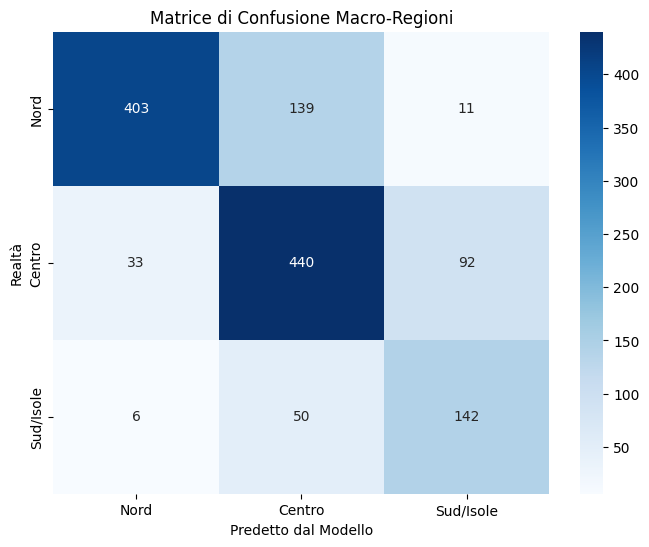

In [ ]:
# REPORT MODELLO
import torch
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from math import radians, cos, sin, asin, sqrt

# --- CONFIGURAZIONE ---
MIN_LAT, MAX_LAT = 35.0, 48.0
MIN_LON, MAX_LON = 6.0, 19.0
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Funzione Distanza (Haversine)
def haversine_np(lon1, lat1, lon2, lat2):
    """
    Calcola distanza in km tra due array di coordinate
    """
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    km = 6371 * c
    return km

def get_macro_region(lat):
    """
    Assegna una classe (Nord, Centro, Sud) basata sulla latitudine.
    Semplificazione utile per calcolare Precision/Recall.
    """
    if lat > 44.0: return "Nord"        # Sopra Bologna
    elif lat > 41.5: return "Centro"    # Tra Roma e Bologna
    else: return "Sud/Isole"            # Sotto Roma

def evaluate_model_comprehensive(model, val_loader):
    print("📊 Inizio Valutazione Completa (questo richiederà un minuto)...")
    model.eval()

    all_preds_coords = []
    all_true_coords = []

    # 1. Raccolta Dati
    with torch.no_grad():
        for imgs, targets in val_loader:
            imgs = imgs.to(device)

            # Predizione
            preds = model(imgs).cpu().numpy()
            targets = targets.numpy()

            # Denormalizzazione Batch
            for i in range(len(preds)):
                p_lat = preds[i][0] * (MAX_LAT - MIN_LAT) + MIN_LAT
                p_lon = preds[i][1] * (MAX_LON - MIN_LON) + MIN_LON

                t_lat = targets[i][0] * (MAX_LAT - MIN_LAT) + MIN_LAT
                t_lon = targets[i][1] * (MAX_LON - MIN_LON) + MIN_LON

                all_preds_coords.append([p_lat, p_lon])
                all_true_coords.append([t_lat, t_lon])

    preds_np = np.array(all_preds_coords)
    true_np = np.array(all_true_coords)

    # 2. Calcolo Errori in Km
    errors_km = haversine_np(preds_np[:,1], preds_np[:,0], true_np[:,1], true_np[:,0])

    print("\n--- 📏 STATISTICHE ERRORE (KM) ---")
    print(f"Errore Medio (Mean):   {np.mean(errors_km):.2f} km")
    print(f"Errore Mediano:        {np.median(errors_km):.2f} km")
    print(f"Errore Minimo:         {np.min(errors_km):.2f} km")
    print(f"Errore Massimo:        {np.max(errors_km):.2f} km")

    # 3. Accuracy @ Threshold (La "Recall" geografica)
    print("\n--- 🎯 ACCURACY @ DISTANZA ---")
    thresholds = [25, 50, 100, 200]
    for th in thresholds:
        acc = np.mean(errors_km <= th) * 100
        print(f"Entro {th} km: {acc:.1f}% delle foto")

    # 4. Precision & Recall per Macro-Regioni
    print("\n--- 🧭 CLASSIFICATION REPORT (NORD/CENTRO/SUD) ---")

    true_regions = [get_macro_region(lat) for lat in true_np[:,0]]
    pred_regions = [get_macro_region(lat) for lat in preds_np[:,0]]

    print(classification_report(true_regions, pred_regions, digits=3))

    # 5. Matrice di Confusione Visiva
    labels = ["Nord", "Centro", "Sud/Isole"]
    cm = confusion_matrix(true_regions, pred_regions, labels=labels)

    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predetto dal Modello')
    plt.ylabel('Realtà')
    plt.title('Matrice di Confusione Macro-Regioni')
    plt.show()

# ESECUZIONE
# Assicurati di passare il 'val_loader' che hai definito prima del training
evaluate_model_comprehensive(model, val_loader)